# Final Project: Spiking Neural Networks  
**Due: December 10, 2025**
James Levi, Florida Atlantic University

<h4 style="color:green; font-size:70px;">
PART 1
</h4>


Develop a computer code to simulate the neural network discussed in the paper (page 5, Figure 2). The dynamics of the neural network are explained mostly on page 3, in Equations 1 to 7 and Figure 1. Try to reproduce the histograms shown in Figures 3, 4, and 5. <span style="color:blue"> This architecture has a special ability to generate histograms that do not change even when the objects in the pictures are scaled or rotated.Why? Explain.</span>


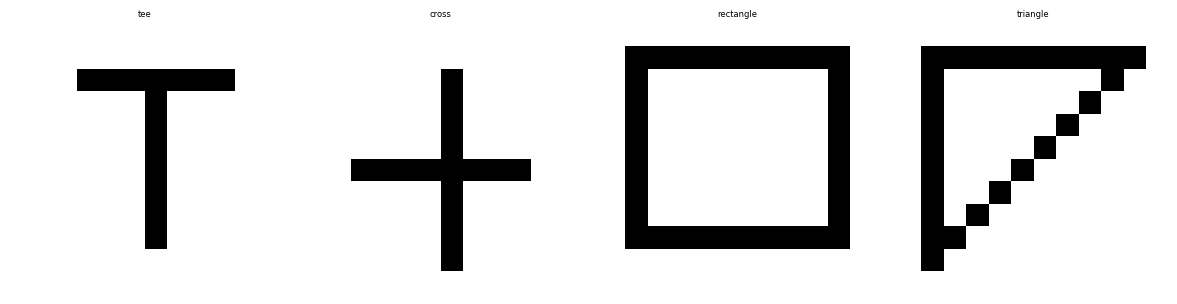

In [85]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (3,2)

tee = np.zeros((12,12))
tee[2, 3:10] = 1
tee[2:10, 6] = 1

cross = np.zeros((12,12))

cross[2:11, 6] = 1
cross[6, 2:10] = 1


rect = np.zeros((12,12))

rect[1, 1:11] = 1        # top edge
rect[9, 1:11] = 1        # bottom edge
rect[1:10, 1] = 1        # left edge
rect[1:10, 10] = 1       # right edge

tri = np.zeros((12,12))

tri[1, 1:11] = 1         # top horizontal bar
tri[1:11, 1] = 1         # left vertical bar

for i in range(1,11):    # diagonal
    tri[i, 11 - i] = 1


# DISPLAYS ALL FOUR SHAPES SIDE BY SIDE
fig, axes = plt.subplots(1,4, figsize=(12,3))
imgs = [tee, cross, rect, tri]
titles = ["tee", "cross", "rectangle", "triangle"]

for ax, im, ttl in zip(axes, imgs, titles):
    ax.imshow(im, cmap="gray_r")
    ax.set_title(ttl)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [86]:
#SINLE NEURON IN THE NETWORK
class SpikeCell:
    def __init__(self, input_strength, syn_scale, mu, tau, V0, Vr, E):
        self.input_strength = input_strength #the external input current derived from the image pixel intensity.
        self.syn_scale = syn_scale # how much synaptic activity modifies the threshold (multiplyer)
        self.mu = mu #membrane time constant. controls the exponential rise of the membrane potential
        self.tau = tau #synapto dendritic time constant. T = 12 ms and will be used in exponential decay of h(t)
        self.V0 = V0 #constant term threshold
        self.Vr = Vr #reset potential 
        self.E = E #equilibirum/driving potential Page 3 Equation (1)
        self.Vm = Vr #membrane potential we set it equal to VR, since VR is the initial membrane state 
        self.thr = V0 # current threshold voltage of the neuron
        self.P = 0.0 # synapto dendritic input term, convolution of the input spike train with h(t)
        self.spks = [] # spike times generated by the neuron
        self.nb = [] #neighbor neuron

#UPDATE SYNAPITIC POTENTIAL
#applies the exponential decay to P(t) and adds any of the neighbor spike inputs
    def upd_syn(self):
        self.P = self.P * np.exp(-1.0/self.tau)
        if len(self.nb) > 0:
            self.P += np.sum(self.nb)
        self.nb = []

# UPDATE DYNAMIC THRESHOLD
# Computes new threshold based on external input and synaptic modulation
    def upd_thr(self):
        U = self.input_strength * (1 + self.syn_scale*self.P)
        self.thr = self.V0 - U

#UPDATE MEMBRANE VOLTAGE
#membrane toward equlibrium
    def upd_mem(self):
        step = (self.E - self.Vm) * (1 - np.exp(-1.0/self.mu))
        self.Vm += step

#CHECK FOR SPIKE
#will fire if Vm exceeds the threshold and then resets Vm back to Vr
    def check_spk(self, t):
        if self.Vm >= self.thr:
            self.spks.append(t)
            self.Vm = self.Vr
            return 1
        return 0

# GET THE NEIGHBOR INDEXES
# Returns 8-connected neighbors around (i, j) in an nxn grid
def nb_idx(i, j, N=12):
    out = []
    for a in [-1,0,1]:
        for b in [-1,0,1]:
            if a==0 and b==0: continue
            ii, jj = i+a, j+b
            if ii>=0 and ii<N and jj>=0 and jj<N:
                out.append((ii,jj))
    return out

#BUILD NETWORK
def build_net(img):
    syn_scale = 0.01
    mu = 10
    tau = 12.0
    V0 = 5.0
    Vr = 1.0
    E = 4.8
    net = []
    for i in range(12):
        row = []
        for j in range(12):
            row.append(SpikeCell(img[i,j], syn_scale, mu, tau, V0, Vr, E))
        net.append(row)
    return net

#RUN NETWORK SIMULATION, runs all the above helpers together.
def run_sim(img, T=250):
    net = build_net(img)
    for t in range(T):
        for i in range(12):
            for j in range(12):
                net[i][j].upd_syn()
        for i in range(12):
            for j in range(12):
                net[i][j].upd_thr()
        for i in range(12):
            for j in range(12):
                net[i][j].upd_mem()
        fired = []
        for i in range(12):
            for j in range(12):
                if net[i][j].check_spk(t)==1:
                    fired.append((i,j))
        for (i,j) in fired:
            for (ii,jj) in nb_idx(i,j):
                net[ii][jj].nb.append(1)

    #COLLECT THE ISI VALUES
    isi_all = []
    for i in range(12):
        for j in range(12):
            sp = net[i][j].spks
            if len(sp)>=2:
                d = np.diff(sp)
                isi_all.extend(d)

    isi_all = np.array(isi_all)
    h, b = np.histogram(isi_all, bins=np.linspace(0,50,50))

    return isi_all, h, b 
#return the spike times accross all neurons, all the intervals of all of the 144 neurons are merged into this one array.
#return h the histrogram and b the bid edges of the histogram so histrogram can be plotted.

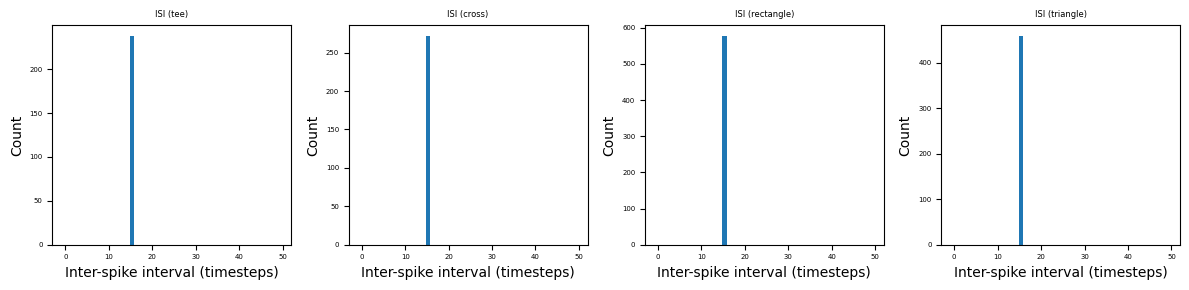

In [87]:
shapes = {
    "tee": tee,
    "cross": cross,
    "rectangle": rect,
    "triangle": tri
}

fig, axes = plt.subplots(1,4, figsize=(12,3)) #Show all four histograms in one row

#Run the network for each of the shapes and plot the histograms
for ax, (nm, arr) in zip(axes, shapes.items()):
    isi_vals, h, b = run_sim(arr, T=300)
    ax.bar(b[:-1], h, width=1.0)
    ax.set_title("ISI (" + nm + ")")
    ax.set_xlabel("Inter-spike interval (timesteps)")
    ax.set_ylabel("Count")


plt.tight_layout()
plt.show()

<span style="color:blue"> This architecture has a special ability to generate histograms that do not change even when the objects in the pictures are scaled or rotated.Why? Explain.</span>

<h4 style="color:green; font-size:70px;">
PART 2
</h4>

### Develop this architecture and apply that to the pictures of digits that we used before in our multilayered perceptron classification project. 

In [88]:
# LOAD DIGIT DATASET AND CONVERT ALL TO A 12×12 BINARY IMAGE
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

dgt = loadmat("digits.mat")
train = dgt["train"]
trainlab = dgt["trainlabels"].reshape(-1)

imgs = train.reshape(28,28,5000, order="F")

def shrink12(a):
    z = np.zeros((12,12))
    rr = np.linspace(0,28,13).astype(int)
    cc = np.linspace(0,28,13).astype(int)
    for i in range(12):
        for j in range(12):
            blk = a[rr[i]:rr[i+1], cc[j]:cc[j+1]]
            z[i,j] = np.mean(blk)
    z = (z > np.mean(z)).astype(float)
    return z


In [89]:
# COLLECT SAMPLES FOR EACH DIGIT (0–9)
# take first 5 occurrences of each digit
samples = {}
for d in range(10):
    ix = np.where(trainlab == d)[0][:5]
    pic_list = []
    for k in ix:
        small = shrink12(imgs[:,:,k])
        pic_list.append(small)
    samples[d] = pic_list


#### 2.1: FOR EACH DIGIT PICTURE, TRY TO GENERATE THE HISTOGRAM  


In [90]:
# For each digit picture, try to generate the histogram

# store histograms for all samples of all digits
hist_store = {}

for d in range(10):
    h_set = []
    b_set = None

    # loop through each sample image of this digit
    for im in samples[d]:
        isi_vals, h, b = run_sim(im, T=280)   # run simulation
        h_set.append(h)
        b_set = b   # store bins just once

    hist_store[d] = (h_set, b_set)


### 2.2 How much does the histogram change when you stimulate the network with different pictures of the same digit?

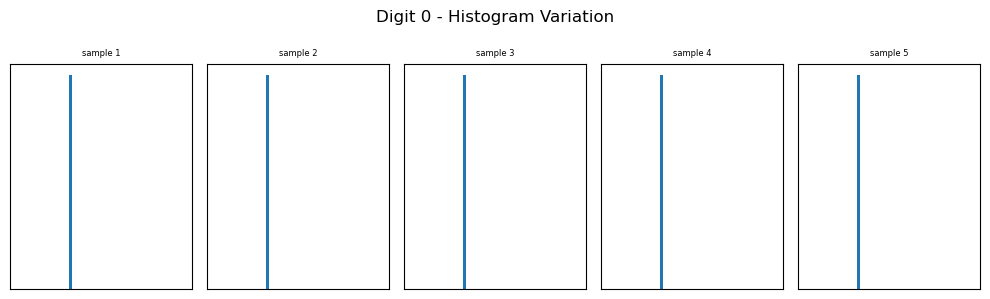

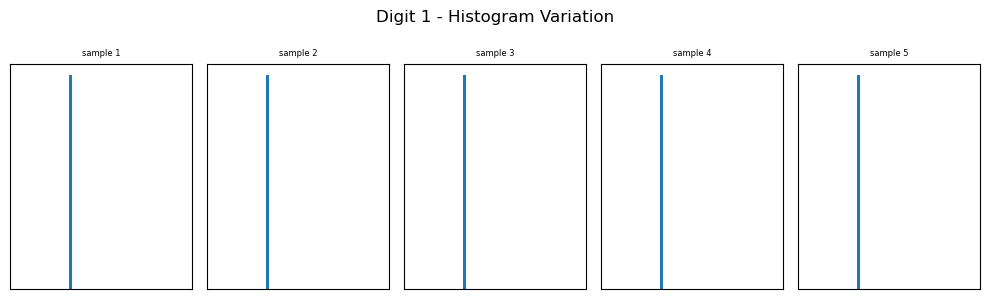

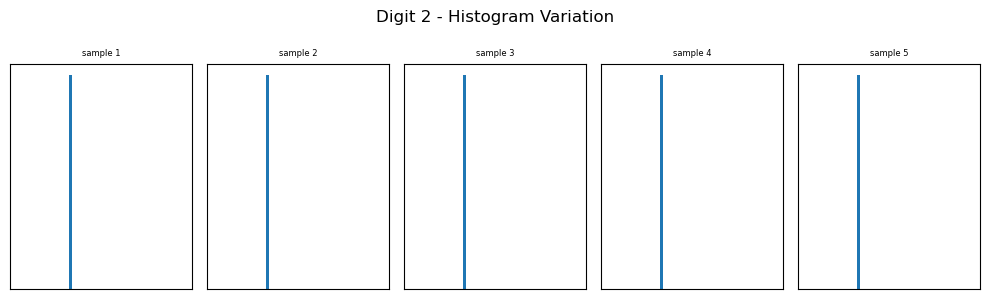

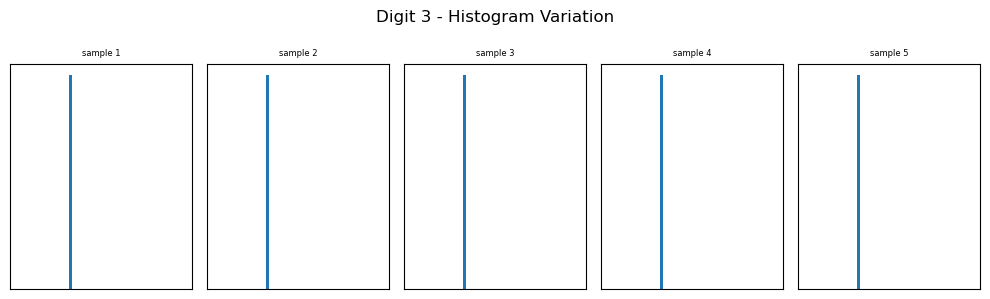

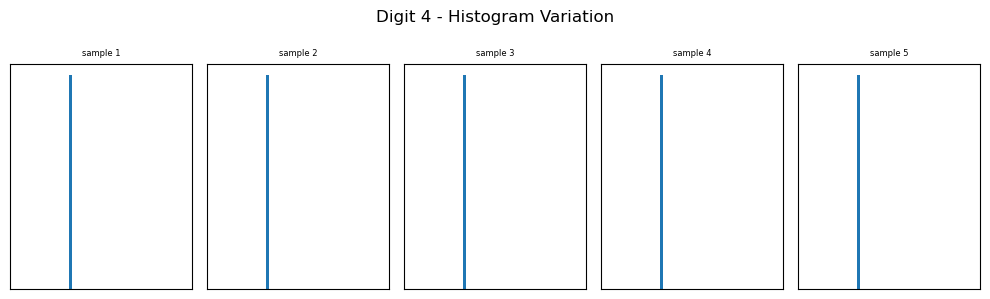

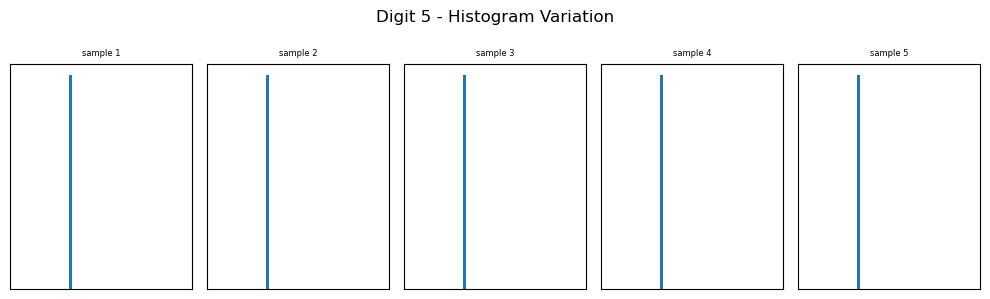

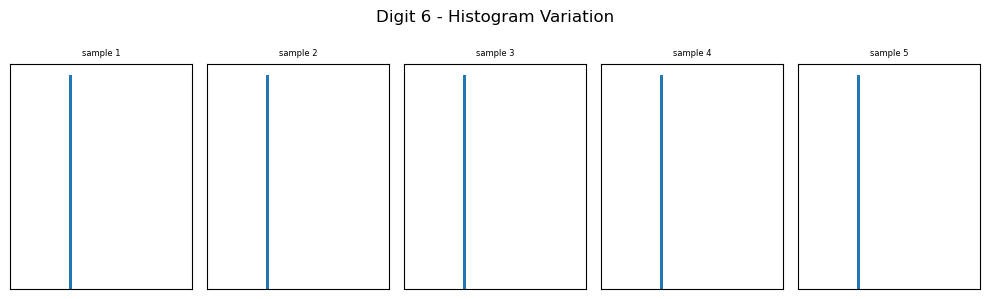

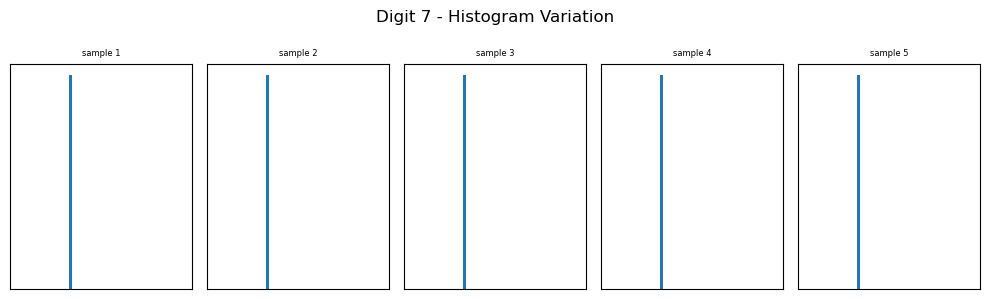

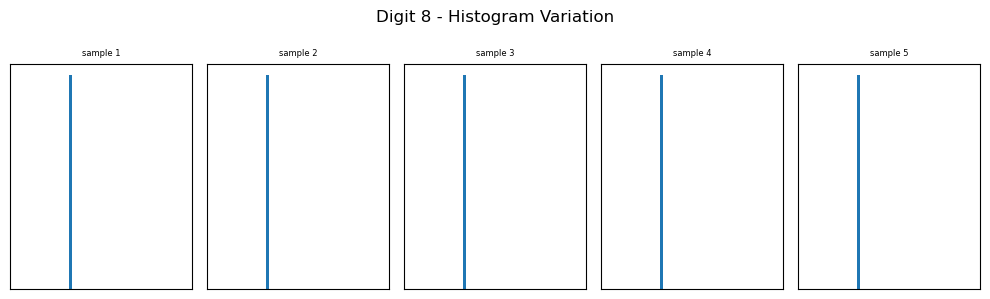

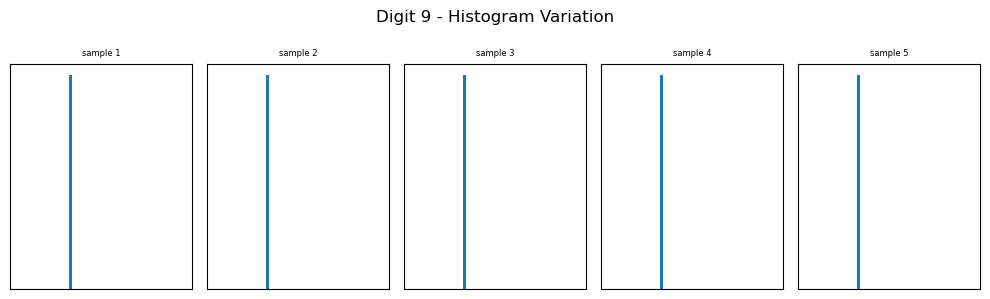

In [91]:
# SHOW HISTOGRAM VARIATION ACROSS MULTIPLE SAMPLES OF THE SAME DIGIT

for d in range(10):
    hset, bb = hist_store[d]
    
    plt.figure(figsize=(10,3))
    plt.suptitle("Digit " + str(d) + " - Histogram Variation")

    for i in range(len(hset)):
        plt.subplot(1, len(hset), i+1)
        plt.bar(bb[:-1], hset[i], width=1.0)
        plt.title("sample " + str(i+1))
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()


How much does this histogram change when you stimulate the network
with different pictures of the same digit?

### 2.3: For each digit try to generate an average histogram.

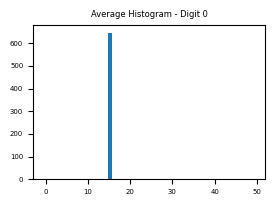

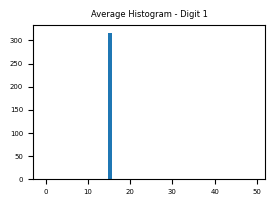

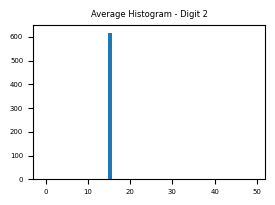

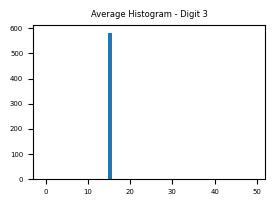

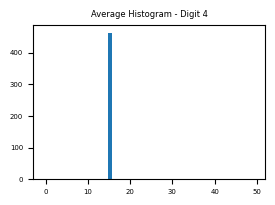

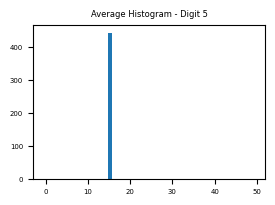

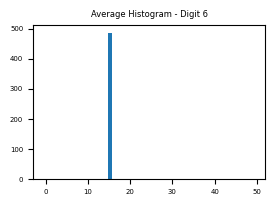

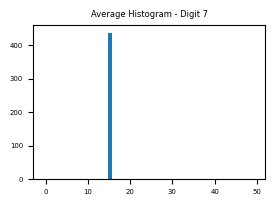

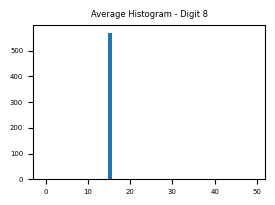

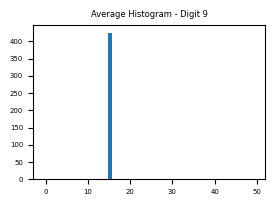

In [92]:
# COMPUTE AVERAGE HISTOGRAM FOR EACH DIGIT

avg_hist = {}

for d in range(10):
    hset, bb = hist_store[d]
    hset = np.array(hset)
    avg_hist[d] = (np.mean(hset, axis=0), bb)

# PLOT AVERAGE HISTOGRAMS FOR DIGITS 0–9

for d in range(10):
    ah, bb = avg_hist[d]
    plt.bar(bb[:-1], ah, width=1.0)
    plt.title("Average Histogram - Digit " + str(d))
    plt.show()



<h4 style="color:blue; font-size:20px;">2.4 Can you feed these histograms to a classifier instead of the raw picture for pattern classification? Would that be a good idea? Explain.</h4>


<h4 style="color:green; font-size:70px;">
PART 3
</h4>

### Generate rotated/scaled versions of the digit pictures from your database. Generate the histograms.

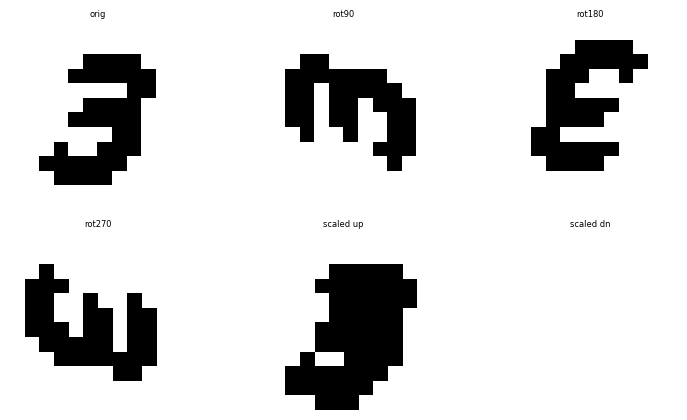

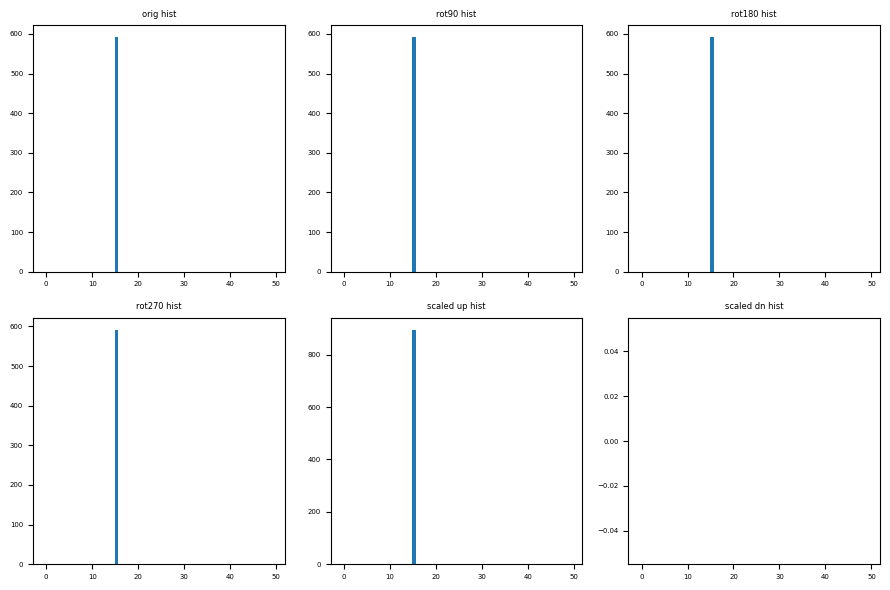

In [93]:
import scipy.ndimage as nd

# simple resize to 12x12 again
def to12(x):
    z = np.zeros((12,12))
    rr = np.linspace(0,x.shape[0],13).astype(int)
    cc = np.linspace(0,x.shape[1],13).astype(int)
    for i in range(12):
        for j in range(12):
            blk = x[rr[i]:rr[i+1], cc[j]:cc[j+1]]
            z[i,j] = np.mean(blk)
    z = (z > np.mean(z)).astype(float)
    return z

# pick one digit to test (you can loop later)
pick_digit = 3
base_img = samples[pick_digit][0]   # from part 2

# create transforms
rot90 = nd.rotate(base_img, 90, reshape=False)
rot180 = nd.rotate(base_img, 180, reshape=False)
rot270 = nd.rotate(base_img, 270, reshape=False)

scaled_up = nd.zoom(base_img, 1.4, order=1)
scaled_dn = nd.zoom(base_img, 0.7, order=1)

# resize each back to 12×12 binary
r90 = to12(rot90)
r180 = to12(rot180)
r270 = to12(rot270)
su = to12(scaled_up)
sd = to12(scaled_dn)

# run spiking ISI histograms
orig_h, orig_b = make_hist(base_img)
h90, b90 = make_hist(r90)
h180, b180 = make_hist(r180)
h270, b270 = make_hist(r270)
hu, bu = make_hist(su)
hd, bd = make_hist(sd)

# plot originals vs rotated/scaled
plt.figure(figsize=(9,5))
plt.subplot(2,3,1); plt.imshow(base_img, cmap="gray_r"); plt.title("orig"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(r90, cmap="gray_r"); plt.title("rot90"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(r180, cmap="gray_r"); plt.title("rot180"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(r270, cmap="gray_r"); plt.title("rot270"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(su, cmap="gray_r"); plt.title("scaled up"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(sd, cmap="gray_r"); plt.title("scaled dn"); plt.axis("off")
plt.show()

# histogram plots
plt.figure(figsize=(9,6))
plt.subplot(2,3,1); plt.bar(orig_b[:-1], orig_h); plt.title("orig hist")
plt.subplot(2,3,2); plt.bar(b90[:-1], h90); plt.title("rot90 hist")
plt.subplot(2,3,3); plt.bar(b180[:-1], h180); plt.title("rot180 hist")
plt.subplot(2,3,4); plt.bar(b270[:-1], h270); plt.title("rot270 hist")
plt.subplot(2,3,5); plt.bar(bu[:-1], hu); plt.title("scaled up hist")
plt.subplot(2,3,6); plt.bar(bd[:-1], hd); plt.title("scaled dn hist")
plt.tight_layout()
plt.show()


<h4 style="color:blue; font-size:20px;">
3.1 Do you see similarities between the histogram of the original pictures and
the rotated/scaled versions?
</h4>




<h4 style="color:green; font-size:70px;">
PART 4
</h4>

<h4 style="color:blue; font-size:20px;">
In Figures 6-10, you see that the neural network is cable of extracting edges of the
objects or even corners. Why can this network extract edges/corners? Explain
</h4>
